# Estructura del dataset

- Session 1: Neutral, Smile
- Session 2: Neutral, surprise, squint
- Session 3: Neutral, smile, disgust
- Session 4: Neutral, Scream, Neutral


In [2]:
import pandas as pd

df = pd.read_csv("/home12TB1/database/recognition/faces/MultiPie/demographic_info_cropped.csv")
print("Unique recordingids:", df['recording_id'].unique())
print("Unique Session IDs", df['session_id'].unique())

Unique recordingids: [2 1 3]
Unique Session IDs ['session01' 'session02' 'session03' 'session04']


# Estadísticas del dataset

Número de usuarios: `748120`

In [10]:
print("Unique user id", df["subject_id"])
print("Number of cameras: ", len(df["camera_id"].unique()))
print("Pics of user 22:", len(df[df["subject_id"] == 22 ])/15)

Unique user id 0         155
1         155
2         155
3         155
4         155
         ... 
748115    342
748116    342
748117    342
748118    342
748119    342
Name: subject_id, Length: 748120, dtype: int64
Number of cameras:  15
Pics of user 22: 218.93333333333334


In [ ]:
print(df[df["subject_id"] == 22].groupby(['session_id', 'recording_id']).size())

session_id  recording_id
session01   1               300
            2               300
session02   1               300
            2               300
            3               300
session03   1               297
            2               300
            3               287
session04   1               300
            2               300
            3               300
dtype: int64


# Número de hombres y mujeres

In [14]:
print("Numero de hombres", len(df[df["gender"] == "Male"]))
print("Numero de mujeres", len(df[df["gender"] == "Female"]))


Numero de hombres 535793
Numero de mujeres 212327


# Numero de hombres y mujeres para las 6 expresiones

In [6]:
import pandas as pd

# 1. Cargar el CSV
df = pd.read_csv("/home12TB1/database/recognition/faces/MultiPie/demographic_info_cropped.csv")

# 2. Función de mapeo corregida
def map_expression(row):
    # Aseguramos que tratamos con strings y enteros limpios
    s = str(row['session_id']).lower() # Convertimos a minúsculas por si acaso
    r = int(row['recording_id'])

    if r == 1: return 0 # Neutral
    
    # Usamos "01" o "session01" dependiendo de cómo venga en tu CSV
    if '01' in s and r == 2: return 1 # Smile
    if '02' in s and r == 2: return 2 # Surprise
    if '02' in s and r == 3: return 3 # Squint
    if '03' in s and r == 2: return 1 # Smile
    if '03' in s and r == 3: return 4 # Disgust
    if '04' in s and r == 2: return 5 # Scream
    if '04' in s and r == 3: return 0 # Neutral
    return -1

# 3. Aplicar
df['expression'] = df.apply(map_expression, axis=1)

# 4. Filtrar y limpiar
df_valid = df[df['expression'] != -1].copy()

# 5. RESULTADOS
print("--- Tabla de Contingencia ---")
# Añadimos margins=True para ver los totales de fila y columna de un vistazo
contingency_table = pd.crosstab(df_valid['expression'], df_valid['gender'], margins=True)
print(contingency_table)

print("\n--- Distribución de Expresiones ---")
# Mapeo de nombres para que sea más fácil de leer
exp_names = {0: "Neutral", 1: "Smile", 2: "Surprise", 3: "Squint", 4: "Disgust", 5: "Scream"}
counts = df_valid['expression'].value_counts().sort_index()
for idx, count in counts.items():
    print(f"{exp_names[idx]}: {count}")

--- Tabla de Contingencia ---
gender      Female    Male     All
expression                        
0            98390  246601  344991
1            40667  101992  142659
2            17105   43617   60722
3            16534   43814   60348
4            19177   49123   68300
5            20454   50646   71100
All         212327  535793  748120

--- Distribución de Expresiones ---
Neutral: 344991
Smile: 142659
Surprise: 60722
Squint: 60348
Disgust: 68300
Scream: 71100


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

CSV_PATH = "/home12TB1/database/recognition/faces/MultiPie/demographic_info_cropped.csv"

def generate_labels(df):
    """
    Generates the 'temp_label' column based on session and recording IDs.
    Returns the modified DataFrame with valid labels only.
    """
    def map_row(row):
        session = str(row['session_id'])
        rec = row['recording_id']

        if rec == 1: 
            return 0  # Neutral
        
        # Session-specific logic
        if 'session01' in session:
            if rec == 2: return 1  # Smile
        elif 'session02' in session:
            if rec == 2: return 2  # Surprise
            if rec == 3: return 3  # Squint
        elif 'session03' in session:
            if rec == 2: return 1  # Smile
            if rec == 3: return 4  # Disgust
        elif 'session04' in session:
            if rec == 2: return 5  # Scream
            if rec == 3: return 0  # Neutral
            
        return -1

    df['temp_label'] = df.apply(map_row, axis=1)
    df = df[df['temp_label'] != -1].reset_index(drop=True)
    return df

def analyze_training_data(csv_path):
    print("Loading data...")
    df = pd.read_csv(csv_path)
    
    # 1. Apply the real label generation for all classes
    df = generate_labels(df)

    # 2. Replicate your Subject-Disjoint Split (70% Train)
    subjects_df = df[['subject_id', 'gender']].drop_duplicates()
    
    train_subs, _ = train_test_split(
        subjects_df,
        test_size=0.3,
        stratify=subjects_df['gender'],
        random_state=42
    )

    # 3. Filter the main dataframe for training subjects
    train_df = df[df['subject_id'].isin(train_subs['subject_id'])]

    # 4. Map numeric labels to names for better readability
    label_map = {
        0: 'Neutral', 1: 'Smile', 2: 'Surprise', 
        3: 'Squint', 4: 'Disgust', 5: 'Scream'
    }
    # Create a copy to avoid SettingWithCopyWarning
    train_df = train_df.copy()
    train_df['Expression'] = train_df['temp_label'].map(label_map)

    # 5. Calculate TOTAL IMAGES and UNIQUE IDENTITIES
    print("\n=== TRAINING SET ANALYSIS (70% SPLIT) ===")
    
    # Group by Expression and Gender
    summary = train_df.groupby(['Expression', 'gender']).agg(
        Total_Images=('subject_id', 'count'),
        Unique_Identities=('subject_id', 'nunique')
    ).reset_index()

    # Sort to match the order: Neutral, Smile, Surprise, Squint, Disgust, Scream
    cat_type = pd.CategoricalDtype(categories=list(label_map.values()), ordered=True)
    summary['Expression'] = summary['Expression'].astype(cat_type)
    summary = summary.sort_values(['Expression', 'gender']).reset_index(drop=True)

    print(summary.to_string(index=False))
    
    # Specifically print the Squint bottleneck info
    print("\n" + "="*40)
    print("THE BOTTLENECK (SQUINT - FEMALES)")
    print("="*40)
    squint_f = summary[(summary['Expression'] == 'Squint') & (summary['gender'] == 'Female')]
    if not squint_f.empty:
        images = squint_f['Total_Images'].values[0]
        identities = squint_f['Unique_Identities'].values[0]
        print(f"-> Max female images available (Your N_limit): {images}")
        print(f"-> Max female identities available: {identities}")
    else:
        print("No female squint data found in this split!")

if __name__ == "__main__":
    analyze_training_data(CSV_PATH)

Loading data...

=== TRAINING SET ANALYSIS (70% SPLIT) ===
Expression gender  Total_Images  Unique_Identities
   Neutral Female         86596                278
   Neutral   Male        221834                301
     Smile Female         35436                233
     Smile   Male         91450                283
  Surprise Female         15137                150
  Surprise   Male         39595                183
    Squint Female         14634                143
    Squint   Male         39743                182
   Disgust Female         16748                155
   Disgust   Male         44155                205
    Scream Female         18172                142
    Scream   Male         45492                211

THE BOTTLENECK (SQUINT - FEMALES)
-> Max female images available (Your N_limit): 14634
-> Max female identities available: 143 (This should match Ivan's chart!)


In [ ]:
import pandas as pd

# Ruta al nuevo CSV
CSV_PATH = "/home12TB1/database/recognition/faces/Multi-Pie/demographic_labels.csv"

def get_emotion_id(session, rec):
    """Tu lógica de mapeo de emociones según sesión y recording_id"""
    # if rec == 1: 
    #     return 0  # Neutral
    
    # if 'session01' in session:
    #     if rec == 1: return 1  # Smile
    # elif 'session02' in session:
    #     if rec == 2: return 2  # Surprise
    #     if rec == 3: return 3  # Squint
    # elif 'session03' in session:
    #     if rec == 2: return 1  # Smile
    #     if rec == 3: return 4  # Disgust
    # elif 'session04' in session:
    #     if rec == 3: return 5  # Scream
    #     if rec == 3: return 0  # Neutral
    # return -1

    if 'session01' in session:
        if rec == 1: return 0 # Neutral
        if rec == 2: return 1 # Smile
    if 'session02' in session:
        if rec == 1: return 0 # Neutral
        if rec == 2: return 2 # Surprise
        if rec == 3: return 3 # Squint
    if 'session03' in session:
        if rec == 1: return 0 # Neutral
        if rec == 2: return 1 # Smile
        if rec == 3: return 4 # Disgust
    if 'session04' in session:
        if rec == 1: return 0 # Neutral
        if rec == 2: return 0 # Neutral
        if rec == 3: return 5 # Scream

# Diccionario inverso para los prints
EMOTION_NAMES = {0: "Neutral", 1: "Smile", 2: "Surprise", 3: "Squint", 4: "Disgust", 5: "Scream"}

print("Cargando CSV...")
df = pd.read_csv(CSV_PATH)

# 1. Filtramos por cámara frontal (05_1 es la frontal en Multi-PIE)
# Si ves que no salen resultados, prueba con 05_0 o revisa tus camera_id
df_frontal = df[df['camera_id'] == '05_1'].copy()

# 2. Aplicamos la lógica de emoción a cada fila
df_frontal['emotion_id'] = df_frontal.apply(
    lambda x: get_emotion_id(x['session_id'], x['recording_id']), axis=1
)

# 3. Quitamos las que no mapean a ninguna emoción de interés
df_frontal = df_frontal[df_frontal['emotion_id'] != -1]

print("\n--- RUTAS ENCONTRADAS PARA TU TFM ---")

for e_id in sorted(EMOTION_NAMES.keys()):
    print(f"\nEMOCIÓN: {EMOTION_NAMES[e_id]} (ID: {e_id})")
    
    for gender in ['Male', 'Female']:
        # Buscamos la primera ocurrencia que cumpla emoción y género
        match = df_frontal[(df_frontal['emotion_id'] == e_id) & (df_frontal['gender'] == gender)].head(1)
        
        if not match.empty:
            path = match['abs_path'].values[0]
            print(f"  [{gender}]: {path}")
        else:
            print(f"  [{gender}]: No se encontró ninguna imagen frontal.")

Cargando CSV...

--- RUTAS ENCONTRADAS PARA TU TFM ---

EMOCIÓN: Neutral (ID: 0)
  [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/155/01/05_1/155_01_01_051_17.png
  [Female]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/068/01/05_1/068_01_01_051_00.png

EMOCIÓN: Smile (ID: 1)
  [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/155/02/05_1/155_01_02_051_01.png
  [Female]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/068/02/05_1/068_01_02_051_04.png

EMOCIÓN: Surprise (ID: 2)
  [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session02/multiview/150/02/05_1/150_02_02_051_17.png
  [Female]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session02/multiview/068/02/05_1/068_02_02_051_16.png

EMOCIÓN: Squint (ID: 3)
  [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session02/multiview/15

In [14]:
import pandas as pd

CSV_PATH = "/home12TB1/database/recognition/faces/Multi-Pie/demographic_labels.csv"
df = pd.read_csv(CSV_PATH)

# Filtramos por cámara frontal para no ensuciar el conteo
df_frontal = df[df['camera_id'] == '05_1']

print("📊 AUDITORÍA DE SESIONES Y RECORDINGS (Cámara 05_1)")
print("-" * 50)

# Agrupamos por sesión y grabación para ver qué existe realmente
summary = df_frontal.groupby(['session_id', 'recording_id']).size().reset_index(name='count')

for session in sorted(summary['session_id'].unique()):
    recs = summary[summary['session_id'] == session]
    rec_list = []
    for _, row in recs.iterrows():
        rec_list.append(f"rec {row['recording_id']} ({row['count']} fotos)")
    
    print(f"🚀 {session}: {', '.join(rec_list)}")

print("-" * 50)

📊 AUDITORÍA DE SESIONES Y RECORDINGS (Cámara 05_1)
--------------------------------------------------
🚀 session01: rec 1 (4980 fotos), rec 2 (4980 fotos)
🚀 session02: rec 1 (4060 fotos), rec 2 (4060 fotos), rec 3 (4060 fotos)
🚀 session03: rec 1 (4600 fotos), rec 2 (4600 fotos), rec 3 (4600 fotos)
🚀 session04: rec 1 (4780 fotos), rec 2 (4780 fotos), rec 3 (4780 fotos)
--------------------------------------------------


In [2]:
import pandas as pd

CSV_PATH = "/home12TB1/database/recognition/faces/Multi-Pie/demographic_labels.csv"
df = pd.read_csv(CSV_PATH)
df_frontal = df[df['camera_id'] == '05_1']

# Definimos las combinaciones que han salido en tu auditoría
sesiones_recs = {
    'session01': [1, 2],
    'session02': [1, 2, 3],
    'session03': [1, 2, 3],
    'session04': [1, 2, 3]
}

print("🔍 EXTRACCIÓN DE MUESTRAS PARA VERIFICACIÓN VISUAL")
print("="*60)

for sess, recs in sesiones_recs.items():
    print(f"\n🚀 {sess.upper()}:")
    for r_id in recs:
        print(f"  --- Recording {r_id} ---")
        for gender in ['Male', 'Female']:
            sample = df_frontal[
                (df_frontal['session_id'] == sess) & 
                (df_frontal['recording_id'] == r_id) & 
                (df_frontal['gender'] == gender)
            ].head(1)
            
            if not sample.empty:
                path = sample['abs_path'].values[0]
                print(f"    [{gender}]: {path}")
            else:
                print(f"    [{gender}]: Sin muestras")

🔍 EXTRACCIÓN DE MUESTRAS PARA VERIFICACIÓN VISUAL

🚀 SESSION01:
  --- Recording 1 ---
    [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/155/01/05_1/155_01_01_051_17.png
    [Female]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/068/01/05_1/068_01_01_051_00.png
  --- Recording 2 ---
    [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/155/02/05_1/155_01_02_051_01.png
    [Female]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session01/multiview/068/02/05_1/068_01_02_051_04.png

🚀 SESSION02:
  --- Recording 1 ---
    [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session02/multiview/150/01/05_1/150_02_01_051_01.png
    [Female]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session02/multiview/068/01/05_1/068_02_01_051_11.png
  --- Recording 2 ---
    [Male]: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped

In [3]:
import pandas as pd

CSV_PATH = "/home12TB1/database/recognition/faces/Multi-Pie/demographic_labels.csv"
df = pd.read_csv(CSV_PATH)

# Filtramos por cámara frontal y Sesión 4
df_s4 = df[(df['camera_id'] == '05_1') & (df['session_id'] == 'session04')]

print("🔍 VERIFICACIÓN VISUAL: SESSION 04 (REC 2 vs REC 3)")
print("="*60)

for r_id in [2, 3]:
    print(f"\n--- 📁 RECORDING {r_id} ---")
    for gender in ['Male', 'Female']:
        samples = df_s4[(df_s4['recording_id'] == r_id) & (df_s4['gender'] == gender)]
        
        if not samples.empty:
            # Sacamos 5 muestras aleatorias para ver que no sea solo "un tío raro"
            n = min(len(samples), 5)
            selected = samples.sample(n=n, random_state=42)
            
            print(f"  🚀 [{gender}]:")
            for i, (idx, row) in enumerate(selected.iterrows(), 1):
                print(f"    {i}. ID {row['subject_id']}: {row['abs_path']}")
        else:
            print(f"  🚀 [{gender}]: No hay muestras.")

🔍 VERIFICACIÓN VISUAL: SESSION 04 (REC 2 vs REC 3)

--- 📁 RECORDING 2 ---
  🚀 [Male]:
    1. ID 251: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/251/02/05_1/251_04_02_051_02.png
    2. ID 122: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/122/02/05_1/122_04_02_051_12.png
    3. ID 220: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/220/02/05_1/220_04_02_051_01.png
    4. ID 128: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/128/02/05_1/128_04_02_051_16.png
    5. ID 346: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/346/02/05_1/346_04_02_051_18.png
  🚀 [Female]:
    1. ID 290: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/290/02/05_1/290_04_02_051_02.png
    2. ID 181: /home12TB1/database/recognition/faces/Multi-Pie/data_cropped/session04/multiview/181/02/05_1/181_04_02_051_06.p

# Comprobación de los csvs generados

In [2]:
import pandas as pd

# fsb_df = pd.read_csv("/home12TB1/database/recognition/faces/affwild2/img2pose_ann/affwild2_train_pose_fsb.csv")
# i2p_df = pd.read_csv("/home12TB1/database/recognition/faces/affwild2/img2pose_ann/affwild2_pose_results_mario.csv")

multipie_df = pd.read_csv("/home12TB1/database/recognition/faces/affectnet/affectnetplus_train_annotations.csv")
print(f"La longitud de affectnet es de {len(multipie_df)}")

# print(f"La longitud del fsb es de {len(fsb_df)}")
# print(f"La longitud del i2p es de {len(i2p_df)}")

La longitud de affectnet es de 287651


In [5]:
import pandas as pd

csv_list = [
    "/home12TB1/database/recognition/faces/affectnet/img2pose_ann/train_pose_fsb.csv",
    "/home12TB1/database/recognition/faces/affectnet/img2pose_ann/val_pose_fsb.csv",
    "/home12TB1/database/recognition/faces/affectnet/img2pose_ann/no_human_annotated_pose_fsb.csv",
    "/home12TB1/database/recognition/faces/RAF-DB/img2pose_ann/train_pose_fsb.csv",
    "/home12TB1/database/recognition/faces/RAF-DB/img2pose_ann/test_pose_fsb.csv"
]

nombres = ['AffectNet Train', 'AffectNet Val', 'AffectNet NHA', 'RAF-DB Train', 'RAF-DB Val']

print(f"{'Dataset':<20} | {'Max FSB':<10} | {'Path del valor más alto'}")
print("-" * 80)

for file, name in zip(csv_list, nombres):
    try:
        df = pd.read_csv(file)
        
        # 1. Encontrar el valor máximo
        max_val = df['FSB'].max()
        
        # 2. Encontrar el path de ese valor máximo
        # Usamos idxmax() para obtener el índice de la fila con el valor más alto
        max_path = df.loc[df['FSB'].idxmax(), 'path']
        
        # 3. Contar cuántos superan el límite de 255
        over_limit = len(df[df['FSB'] > 255])
        
        print(f"{name:<20} | {max_val:>10.2f} | {max_path}")
        if over_limit > 0:
            print(f"   --> ¡OJO! Hay {over_limit} filas que superan el valor de 255.")
            
    except Exception as e:
        print(f"Error en {name}: {e}")

Dataset              | Max FSB    | Path del valor más alto
--------------------------------------------------------------------------------
AffectNet Train      |     254.19 | //home12TB1/database/recognition/faces/affectnet/human_annotated/train_set/images/91432.jpg
AffectNet Val        |     252.87 | //home12TB1/database/recognition/faces/affectnet/human_annotated/validation_set/images/2682.jpg
AffectNet NHA        |     254.47 | /home12TB1/database/recognition/faces/affectnet/no_human_annotated/images/35766.jpg
RAF-DB Train         |     244.68 | /home12TB1/database/recognition/faces/RAF-DB/Image/aligned/train_04762_aligned.jpg
RAF-DB Val           |     240.84 | /home12TB1/database/recognition/faces/RAF-DB/Image/aligned/test_2515_aligned.jpg


In [13]:
import pandas as pd

df = pd.read_csv("/home12TB1/database/recognition/faces/affectnet/affectnetplus_test_annotations_quality_illum.csv")

# Binarizamos para no perder datos por culpa de los floats
df['gender_male_bin'] = (df['gender_male'] > 0.5).astype(int)
df['gender_name'] = df['gender_male_bin'].map({0: 'Female', 1: 'Male'})

# Esta tabla te dará los números REALES de lo que hay en el CSV
print("Mínimos reales por clase:")
print(df['human_label'].value_counts())

contingency_table = pd.crosstab(
    df['human_label'], 
    df['gender_name'], 
    margins=True
)
contingency_table

Mínimos reales por clase:
human_label
7    500
3    500
4    500
5    500
6    500
2    500
1    500
0    499
Name: count, dtype: int64


gender_name,Female,Male,All
human_label,,,
0,149,350,499
1,221,279,500
2,121,379,500
3,157,343,500
4,129,371,500
5,94,406,500
6,55,445,500
7,128,372,500
All,1054,2945,3999


In [12]:
import pandas as pd

df = pd.read_csv("/home12TB1/database/recognition/faces/affectnet/affectnetplus_train_annotations.csv")

# Binarizamos para no perder datos por culpa de los floats
df['gender_male_bin'] = (df['gender_male'] > 0.5).astype(int)
df['gender_name'] = df['gender_male_bin'].map({0: 'Female', 1: 'Male'})

# Esta tabla te dará los números REALES de lo que hay en el CSV
print("Mínimos reales por clase:")
print(df['human_label'].value_counts())

contingency_table = pd.crosstab(
    df['human_label'], 
    df['gender_name'], 
    margins=True
)
contingency_table

Mínimos reales por clase:
human_label
1    134415
0     74874
2     25459
6     24882
3     14090
4      6378
5      3803
7      3750
Name: count, dtype: int64


gender_name,Female,Male,All
human_label,,,
0,20229,54645,74874
1,53797,80618,134415
2,5973,19486,25459
3,4284,9806,14090
4,1723,4655,6378
5,713,3090,3803
6,2735,22147,24882
7,1073,2677,3750
All,90527,197124,287651


In [11]:
import pandas as pd

# 1. Cargar datos
df = pd.read_csv("/home12TB1/database/recognition/faces/affectnet/affectnetplus_train_annotations.csv")

# 2. Replicar la lógica de tu DataModule (IMPORTANTE)
# AffectNet tiene floats, hay que binarizar antes de mapear
df['gender_male_bin'] = (df['gender_male'] > 0.5).astype(int)
df['gender_female_bin'] = (df['gender_female'] > 0.5).astype(int)

# --- APLICAR TU LÓGICA DE BALANCEO ---
counts = df['human_label'].value_counts()
global_target = counts.min()
target_per_gender = global_target // 2

final_dfs = []
for label in df['human_label'].unique():
    women_df = df[(df['human_label'] == label) & (df['gender_female_bin'] == 1)]
    men_df = df[(df['human_label'] == label) & (df['gender_male_bin'] == 1)]
    
    n_w, n_m = len(women_df), len(men_df)

    if n_w >= target_per_gender and n_m >= target_per_gender:
        s_women = women_df.sample(n=target_per_gender, random_state=42)
        s_men = men_df.sample(n=target_per_gender, random_state=42)
    elif n_w < target_per_gender:
        s_women = women_df
        s_men = men_df.sample(n=min(global_target - n_w, n_m), random_state=42)
    else:
        s_men = men_df
        s_women = women_df.sample(n=min(global_target - n_m, n_w), random_state=42)
    
    final_dfs.extend([s_women, s_men])

df_balanced = pd.concat(final_dfs)

# 3. Crear tabla de contingencia del set BALANCEADO
df_balanced['gender_name'] = df_balanced['gender_male_bin'].map({0: 'Female', 1: 'Male'})

contingency_table = pd.crosstab(
    df_balanced['human_label'], 
    df_balanced['gender_name'], 
    margins=True, 
    margins_name="Total"
)

contingency_table

gender_name,Female,Male,Total
human_label,,,
0,1875,1875,3750
1,1875,1875,3750
2,1875,1875,3750
3,1875,1875,3750
4,1712,2038,3750
5,706,3044,3750
6,1875,1875,3750
7,1069,2677,3746
Total,12862,17134,29996


In [ ]:
# Estudiar anotaciones Affectnet human_label vs soft

import pandas as pd
import numpy as np

df = pd.read_csv("/home12TB1/database/recognition/faces/affectnet/affectnetplus_train_annotations.csv")
print(f"La cantidad de datos en affectnet es de {len(df)}")


soft_cols = [f'soft_{i}' for i in range(8)]

# 3. Obtener la predicción del "modelo soft" (la clase con mayor probabilidad)
# idxmax devuelve el nombre de la columna con el valor máximo
df['soft_prediction'] = df[soft_cols].idxmax(axis=1).str.replace('soft_', '').astype(int)

# 4. Calcular la coincidencia
df['match'] = df['human_label'] == df['soft_prediction']

# 5. Agrupar por emoción humana para ver el desastre por clases
report = df.groupby('human_label').agg(
    total_images=('match', 'count'),
    matches=('match', 'sum'),
    accuracy_vs_soft=('match', 'mean')
).reset_index()

# Mapeo de nombres para que se entienda mejor
emotions = {0: 'Neutral', 1: 'Happy', 2: 'Sad', 3: 'Surprise', 
            4: 'Fear', 5: 'Disgust', 6: 'Anger', 7: 'Contempt'}
report['emotion_name'] = report['human_label'].map(emotions)

print("--- REPORTE DE COINCIDENCIA: HUMANO vs SOFT LABELS ---")
print(report[['human_label', 'emotion_name', 'total_images', 'accuracy_vs_soft']])

# 6. Bonus: ¿A qué clase se va el error? (Matriz de confusión de etiquetas)
print("\n--- MATRIZ DE DISCREPANCIA (Filas: Humano, Columnas: Soft) ---")
discrepancy_matrix = pd.crosstab(df['human_label'], df['soft_prediction'], normalize='index')
print(discrepancy_matrix)

La cantidad de datos en affectnet es de 287651
--- REPORTE DE COINCIDENCIA: HUMANO vs SOFT LABELS ---
   human_label emotion_name  total_images  accuracy_vs_soft
0            0      Neutral         74874          0.686874
1            1        Happy        134415          0.862508
2            2          Sad         25459          0.320987
3            3     Surprise         14090          0.348758
4            4         Fear          6378          0.266071
5            5      Disgust          3803          0.259532
6            6        Anger         24882          0.428020
7            7     Contempt          3750          0.127200

--- MATRIZ DE DISCREPANCIA (Filas: Humano, Columnas: Soft) ---
soft_prediction         0         1         2         3         4         5  \
human_label                                                                   
0                0.686874  0.101357  0.050966  0.031052  0.011045  0.020314   
1                0.065930  0.862508  0.011628  0.008593  

# Estudio de affwild2


In [6]:
import pandas as pd

df = pd.read_csv("/home12TB1/database/recognition/faces/affwild2/dataframe_train.csv")



print(f"El dataset de train de affwild2 tiene {len(df)} filas")
print(f"Columnas: {df.columns}")

distribucion = df['expr_name'].value_counts()
porcentaje = df['expr_name'].value_counts(normalize=True) * 100
print(pd.concat([distribucion, porcentaje], axis=1))

# 1. ¿Cuántos NaNs reales hay en la columna expr?
nans_expr = df['expr'].isna().sum()

# 2. ¿Hay valores centinela (tipo -1) que signifiquen "sin etiqueta"?
# En Aff-Wild2, a veces usan -1 para frames no anotados en esa tarea.
no_label = (df['expr'] == -1).sum() 

# 3. Ver el resumen total
print(f"Total filas: {len(df)}")
print(f"Filas con NaN en expr: {nans_expr}")
print(f"Filas con valor -1 (sin etiqueta): {no_label}")
print(f"Filas con etiquetas válidas (0-7): {df['expr'].isin(range(8)).sum()}")

/tmp/ipykernel_61275/770135674.py:3: DtypeWarning: Columns (1,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home12TB1/database/recognition/faces/affwild2/dataframe_train.csv")


El dataset de train de affwild2 tiene 1747745 filas
Columnas: Index(['image_path', 'video', 'frame_idx', 'subject', 'split', 'valence',
       'arousal', 'expr', 'expr_name', 'AU1', 'AU2', 'AU4', 'AU6', 'AU7',
       'AU10', 'AU12', 'AU15', 'AU23', 'AU24', 'AU25', 'AU26'],
      dtype='object')
            count  proportion
expr_name                    
Neutral    177498   30.240272
Other      165866   28.258533
Happiness   95633   16.292961
Sadness     79862   13.606061
Surprise    31637    5.389985
Anger       16573    2.823536
Disgust     10810    1.841696
Fear         9080    1.546956
Total filas: 1747745
Filas con NaN en expr: 1160786
Filas con valor -1 (sin etiqueta): 0
Filas con etiquetas válidas (0-7): 586959


Total filas válidas tras dropna: 586959
Sujetos reales detectados (carpetas): 247
Ejemplo de IDs de sujetos (ahora sí): ['1-30-1280x720' '10-60-1280x720' '10-60-1280x720_right'
 '100-29-1080x1920' '101-30-1080x1920']

--- Estadísticas tras filtrar por SUJETO REAL ---
   expr  total_subjects  total_frames_available
0   0.0             202                   37602
1   1.0              32                    4958
2   2.0              19                    2999
3   3.0              14                    2230
4   4.0             163                   29553
5   5.0              32                    6068
6   6.0              71                    8603
7   7.0             110                   25002


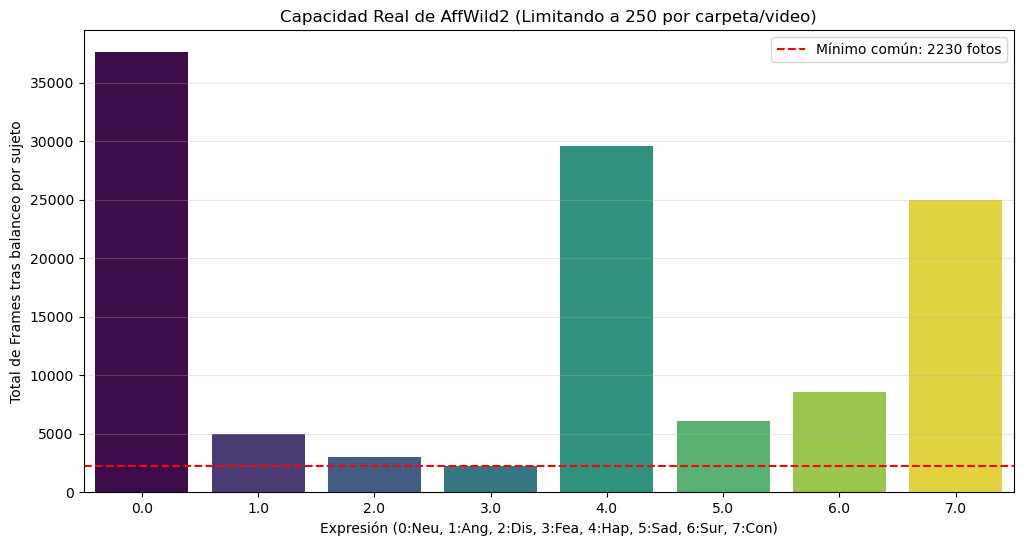


✅ Análisis completado:
Ahora la clase limitante (3.0) tiene 14 sujetos reales.
Tu dataset pasará de 2.000 fotos a aproximadamente 17840 fotos totales.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Carga con optimización de memoria
df = pd.read_csv("/home12TB1/database/recognition/faces/affwild2/dataframe_train.csv", low_memory=False)
MAX_FRAMES_PER_SUBJECT = 250

# --- CORRECCIÓN 1: Limpieza de NaNs ---
df = df.dropna(subset=['expr'])

# --- CORRECCIÓN 2: Extracción Robusta del Sujeto ---
# Usamos os.path para evitar fallos con las '/' iniciales.
# dirname saca la carpeta, y basename el nombre de esa carpeta final.
def extract_subject(path):
    # '/data/123/0001.jpg' -> folder: '/data/123' -> basename: '123'
    return os.path.basename(os.path.dirname(path))

df['real_subject'] = df['image_path'].apply(extract_subject)

print(f"Total filas válidas tras dropna: {len(df)}")
print(f"Sujetos reales detectados (carpetas): {df['real_subject'].nunique()}")
print(f"Ejemplo de IDs de sujetos (ahora sí): {df['real_subject'].unique()[:5]}")

# 2. Simular el recorte por sujeto REAL
# Agrupamos por expresión y por el ID de la CARPETA (sujeto real)
df_counts = df.groupby(['expr', 'real_subject']).size().reset_index(name='original_count')
df_counts['limited_count'] = df_counts['original_count'].apply(lambda x: min(x, MAX_FRAMES_PER_SUBJECT))

# 3. Agrupar por emoción para ver el total disponible tras el recorte
stats_per_expr = df_counts.groupby('expr').agg(
    total_subjects=('real_subject', 'nunique'),
    total_frames_available=('limited_count', 'sum')
).reset_index()

print("\n--- Estadísticas tras filtrar por SUJETO REAL ---")
print(stats_per_expr)

# 4. Visualización
plt.figure(figsize=(12, 6))

# Usamos hue=expr para evitar el warning de Seaborn
sns.barplot(data=stats_per_expr, x='expr', y='total_frames_available', hue='expr', palette='viridis', legend=False)

min_val = stats_per_expr['total_frames_available'].min()
plt.axhline(y=min_val, color='red', linestyle='--', 
            label=f"Mínimo común: {int(min_val)} fotos")

plt.title(f'Capacidad Real de AffWild2 (Limitando a {MAX_FRAMES_PER_SUBJECT} por carpeta/video)')
plt.xlabel('Expresión (0:Neu, 1:Ang, 2:Dis, 3:Fea, 4:Hap, 5:Sad, 6:Sur, 7:Con)')
plt.ylabel('Total de Frames tras balanceo por sujeto')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("affwild2_downsampling.svg")
plt.show()

# 5. El veredicto
min_expr = stats_per_expr.loc[stats_per_expr['total_frames_available'].idxmin()]
print(f"\n✅ Análisis completado:")
print(f"Ahora la clase limitante ({min_expr['expr']}) tiene {int(min_expr['total_subjects'])} sujetos reales.")
print(f"Tu dataset pasará de 2.000 fotos a aproximadamente {int(min_val * 8)} fotos totales.")

In [5]:
# --- CORRECCIÓN DE RUTA ---
# Si la ruta es '/data/123/001.jpg', queremos '123'. 
# Usamos os.path.dirname para obtener el directorio y luego sacamos el nombre de la carpeta final.

def extract_subject(path):
    # Esto quita el nombre del archivo y se queda con la carpeta
    parent_dir = os.path.dirname(path) 
    # Esto saca el nombre de la carpeta final (ej: '123')
    subject_id = os.path.basename(parent_dir)
    return subject_id

df['real_subject'] = df['image_path'].apply(extract_subject)

# --- VERIFICACIÓN ---
print(f"Total filas válidas: {len(df)}")
print(f"Sujetos reales detectados: {df['real_subject'].nunique()}")
print(f"Ejemplo de IDs de sujetos (ahora sí): {df['real_subject'].unique()[:5]}")

Total filas válidas: 586959
Sujetos reales detectados: 247
Ejemplo de IDs de sujetos (ahora sí): ['1-30-1280x720' '10-60-1280x720' '10-60-1280x720_right'
 '100-29-1080x1920' '101-30-1080x1920']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


df = pd.read_csv("/home12TB1/database/recognition/faces/affectnet/affectnetplus_train_annotations.csv")

# AffectNet suele usar etiquetas: 0:Neu, 1:Hap, 2:Sad, 3:Sur, 4:Fea, 5:Dis, 6:Ang, 7:Con
# (Verifica si tu CSV usa este orden o el de AffWild2)

# --- PASO 1: Análisis de la distribución original ---
original_counts = df['human_label'].value_counts().sort_index().reset_index()
original_counts.columns = ['label', 'count']

# --- PASO 2: Lógica de Downsampling ---
# En AffectNet, al no haber sujetos repetidos por vídeo, el límite lo marca 
# la clase minoritaria para un balanceo perfecto (Undersampling).
target_n = original_counts['count'].min() 

print(f"Total imágenes originales: {len(df)}")
print(f"Clase limitante en AffectNet tiene: {target_n} imágenes")

# --- PASO 3: Visualización ---
plt.figure(figsize=(12, 7))

# Gráfico de barras original
sns.set_style("whitegrid")
ax = sns.barplot(data=original_counts, x='label', y='count', palette='magma', hue='label', legend=False)

# LÍNEA DE DOWNSAMPLING (El "suelo" del dataset balanceado)
plt.axhline(y=target_n, color='red', linestyle='--', linewidth=2,
            label=f"Nivel de Balanceo (Clase min): {target_n}")

# Añadir etiquetas de texto sobre las barras para ver el "desperdicio" de datos
for i, p in enumerate(ax.patches):
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.title('Distribución Original de AffectNet vs. Límite de Balanceo', fontsize=15)
plt.xlabel('Etiqueta de Expresión', fontsize=12)
plt.ylabel('Número de Imágenes', fontsize=12)
plt.legend(fontsize=11)

# Anotación técnica para la presentación
plt.annotate(f'Dataset resultante:\n{target_n} x 8 clases = {target_n*8} imágenes',
             xy=(7, target_n), xytext=(5, target_n*3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=12, bbox=dict(boxstyle="round", fc="0.9"))

plt.tight_layout()
plt.savefig("affectnet_downsampling_balance.svg")
plt.show()

print("\n✅ Resumen para la diapositiva:")
print(f"AffectNet es mucho más masivo pero está muy sesgado.")
print(f"Al balancear, descartamos el excedente de las clases mayoritarias")
print(f"para evitar que la ResNet aprenda a predecir 'Neutral' por estadística.")

KeyError: 'label'